#Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Project Config

In [ ]:
PROJECT_NAME = "credit_card_default_v1"
BASE_PATH = f"/content/drive/MyDrive/ml_projects/{PROJECT_NAME}/"
DATA_RAW_PATH = BASE_PATH + "data/raw/"
MODEL_PATH = BASE_PATH + "models/"
DATA_PREPROCESSED_PATH = BASE_PATH + "data/preprocessed/"
NOTEBOOKS_PATH = BASE_PATH + "notebooks/"
import os

folders = [
    DATA_RAW_PATH,
    MODEL_PATH,
    DATA_PREPROCESSED_PATH,
    NOTEBOOKS_PATH
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created successfully.")


Project folders created successfully.


#Kaggle Setup and Download Dataset

In [ ]:
!mkdir -p ~/.kaggle
!cp /content/drive/MyDrive/kaggle/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle API configured successfully.")

%cd {DATA_RAW_PATH}

!kaggle datasets download -d uciml/default-of-credit-card-clients-dataset

Kaggle API configured successfully.
/content/drive/MyDrive/ml_projects/credit_card_default_v1/data/raw
Dataset URL: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset
License(s): CC0-1.0
default-of-credit-card-clients-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


#Unzip Dataset( First Run )

In [ ]:
#!unzip default-of-credit-card-clients-dataset.zip

In [ ]:
import os

print(os.getcwd())

/content/drive/MyDrive/ml_projects/credit_card_default_v1/data/raw


# Credit Card Default — Complete ML & Deep Learning Pipeline
### Dataset: Default of Credit Card Clients in Taiwan (April–September 2005)
**Goal:** Predict whether a customer will default on their next credit card payment.

---

## Table of Contents

1. [Setup & Data Loading](#step1)
2. [Exploratory Data Analysis (EDA)](#step2)
3. [Data Preprocessing & Feature Engineering](#step3)
4. [Baseline ML Models + MLflow Tracking](#step4)
5. [Hyperparameter Tuning with Optuna](#step5)
6. [Custom Deep Learning Architecture (PyTorch)](#step6)
7. [Model Comparison & Final Evaluation](#step7)
8. [MLOps — Model Registry & Serving](#step8)

---

## Dataset Summary

| Property | Detail |
|---|---|
| Source | UCI Machine Learning Repository |
| Period | April 2005 – September 2005 |
| Region | Taiwan |
| Rows | 30,000 customers |
| Columns | 25 features |
| Target | `default.payment.next.month` (0 = No, 1 = Yes) |
| Class Split | 77.9% No Default / 22.1% Default |

---

## Feature Groups

| Group | Features |
|---|---|
| Demographics | `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` |
| Credit Limit | `LIMIT_BAL` |
| Repayment Status | `PAY_0`, `PAY_2`, `PAY_3`, `PAY_4`, `PAY_5`, `PAY_6` |
| Bill Amounts | `BILL_AMT1` → `BILL_AMT6` (Sep–Apr) |
| Payment Amounts | `PAY_AMT1` → `PAY_AMT6` (Sep–Apr) |
| Target | `default.payment.next.month` |

---

## Pipeline Overview

```
Raw Data → EDA → Preprocessing → Baseline ML → Hyperparameter Tuning
                                                         ↓
                               MLOps ← Model Comparison ← Deep Learning
```

---

> **All experiments are tracked with MLflow.**
> Best model is registered to the MLflow Model Registry and tagged as `Production`.

# Step 1 -- Setup and Data Loading

In [ ]:
# Install
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost lightgbm shap -q

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing   import LabelEncoder

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120


df = pd.read_csv("UCI_Credit_Card.csv")
df.rename(columns={"default.payment.next.month": "default"}, inplace=True)
df.drop(columns=["ID"], inplace=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
0,20000.0,2,2,1,24,2,2,-1,-1,-2,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,120000.0,2,2,2,26,-1,2,0,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,90000.0,2,2,2,34,0,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,50000.0,2,2,1,37,0,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,50000.0,1,2,1,57,-1,0,-1,0,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


---
## Step 2 — Exploratory Data Analysis (EDA)
<a id="step2"></a>
> Understand distributions, correlations, outliers, and default patterns across all features.

##Basic Overview

Before diving into plots, let's understand what's in the data — shape, types, missing values, and basic stats.

In [ ]:
print("─── DTYPES ───")
print(df.dtypes)

print("\n─── NULL COUNTS ───")
print(df.isnull().sum())

print("\n─── DUPLICATES ───")
print(f"Duplicate rows: {df.duplicated().sum()}")

print("\n─── DESCRIBE ───")
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean","std"])

─── DTYPES ───
LIMIT_BAL    float64
SEX            int64
EDUCATION      int64
MARRIAGE       int64
AGE            int64
PAY_0          int64
PAY_2          int64
PAY_3          int64
PAY_4          int64
PAY_5          int64
PAY_6          int64
BILL_AMT1    float64
BILL_AMT2    float64
BILL_AMT3    float64
BILL_AMT4    float64
BILL_AMT5    float64
BILL_AMT6    float64
PAY_AMT1     float64
PAY_AMT2     float64
PAY_AMT3     float64
PAY_AMT4     float64
PAY_AMT5     float64
PAY_AMT6     float64
default        int64
dtype: object

─── NULL COUNTS ───
LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
PAY_AMT4     0
PAY_AMT5     0
PAY_AMT6     0
default      0
dtype: int64

─── DUPLICATES ───
Duplicate rows: 35

─── DESCRIBE ───


,count,mean,std,min,25%,50%,75%,max
LIMIT_BAL,30000.000000,167484.322667,129747.661567,10000.000000,50000.000000,140000.000000,240000.000000,1000000.000000
SEX,30000.000000,1.603733,0.489129,1.000000,1.000000,2.000000,2.000000,2.000000
EDUCATION,30000.000000,1.853133,0.790349,0.000000,1.000000,2.000000,2.000000,6.000000
MARRIAGE,30000.000000,1.551867,0.521970,0.000000,1.000000,2.000000,2.000000,3.000000
AGE,30000.000000,35.485500,9.217904,21.000000,28.000000,34.000000,41.000000,79.000000
PAY_0,30000.000000,-0.016700,1.123802,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_2,30000.000000,-0.133767,1.197186,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_3,30000.000000,-0.166200,1.196868,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_4,30000.000000,-0.220667,1.169139,-2.000000,-1.000000,0.000000,0.000000,8.000000
PAY_5,30000.000000,-0.266200,1.133187,-2.000000,-1.000000,0.000000,0.000000,8.000000


##Target Variable Analysis

Understanding **class imbalance** is critical — imbalanced targets need special handling during model training.

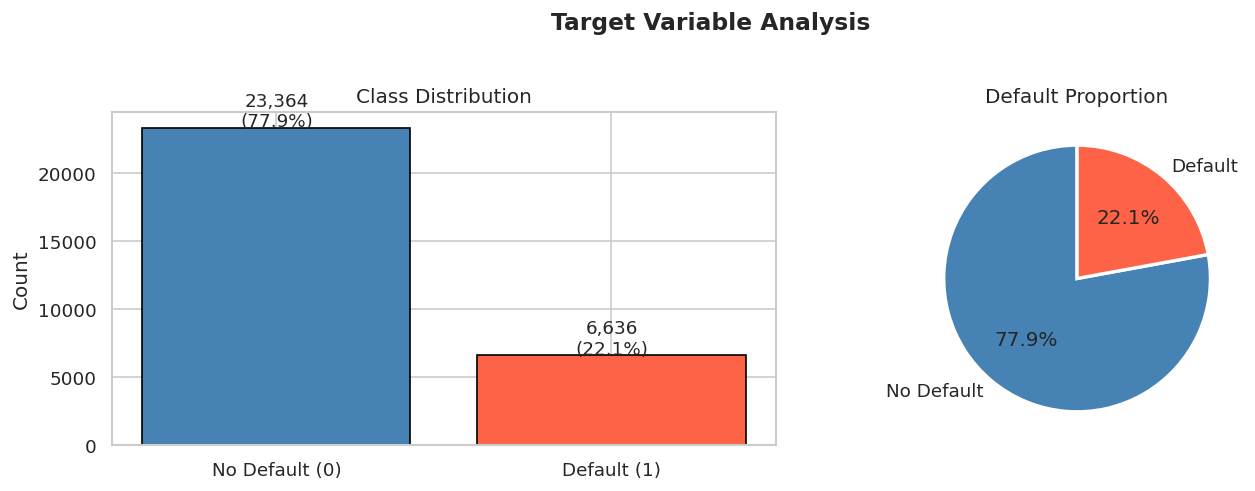

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
counts = df["default"].value_counts()
axes[0].bar(["No Default (0)", "Default (1)"],
            counts.values, color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, f"{v:,}\n({v/len(df)*100:.1f}%)",
                 ha="center", fontsize=11)

# Pie
axes[1].pie(counts.values, labels=["No Default", "Default"],
            colors=["steelblue","tomato"], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Default Proportion")

plt.suptitle("Target Variable Analysis", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# ─── ML NOTE ───────────────────────────────────────────────────────
# 77.9% vs 22.1% → moderate imbalance
# ML fix:   class_weight="balanced" in Logistic Regression / RF
#           scale_pos_weight = 23364/6636 ≈ 3.52  in XGBoost/LightGBM
# DL fix:   Focal Loss (alpha=0.75, gamma=2) — do NOT use BCELoss raw
# ───────────────────────────────────────────────────────────────────

##Demographic Analysis

Exploring how **Gender, Education, Marriage, and Age** relate to default rates.

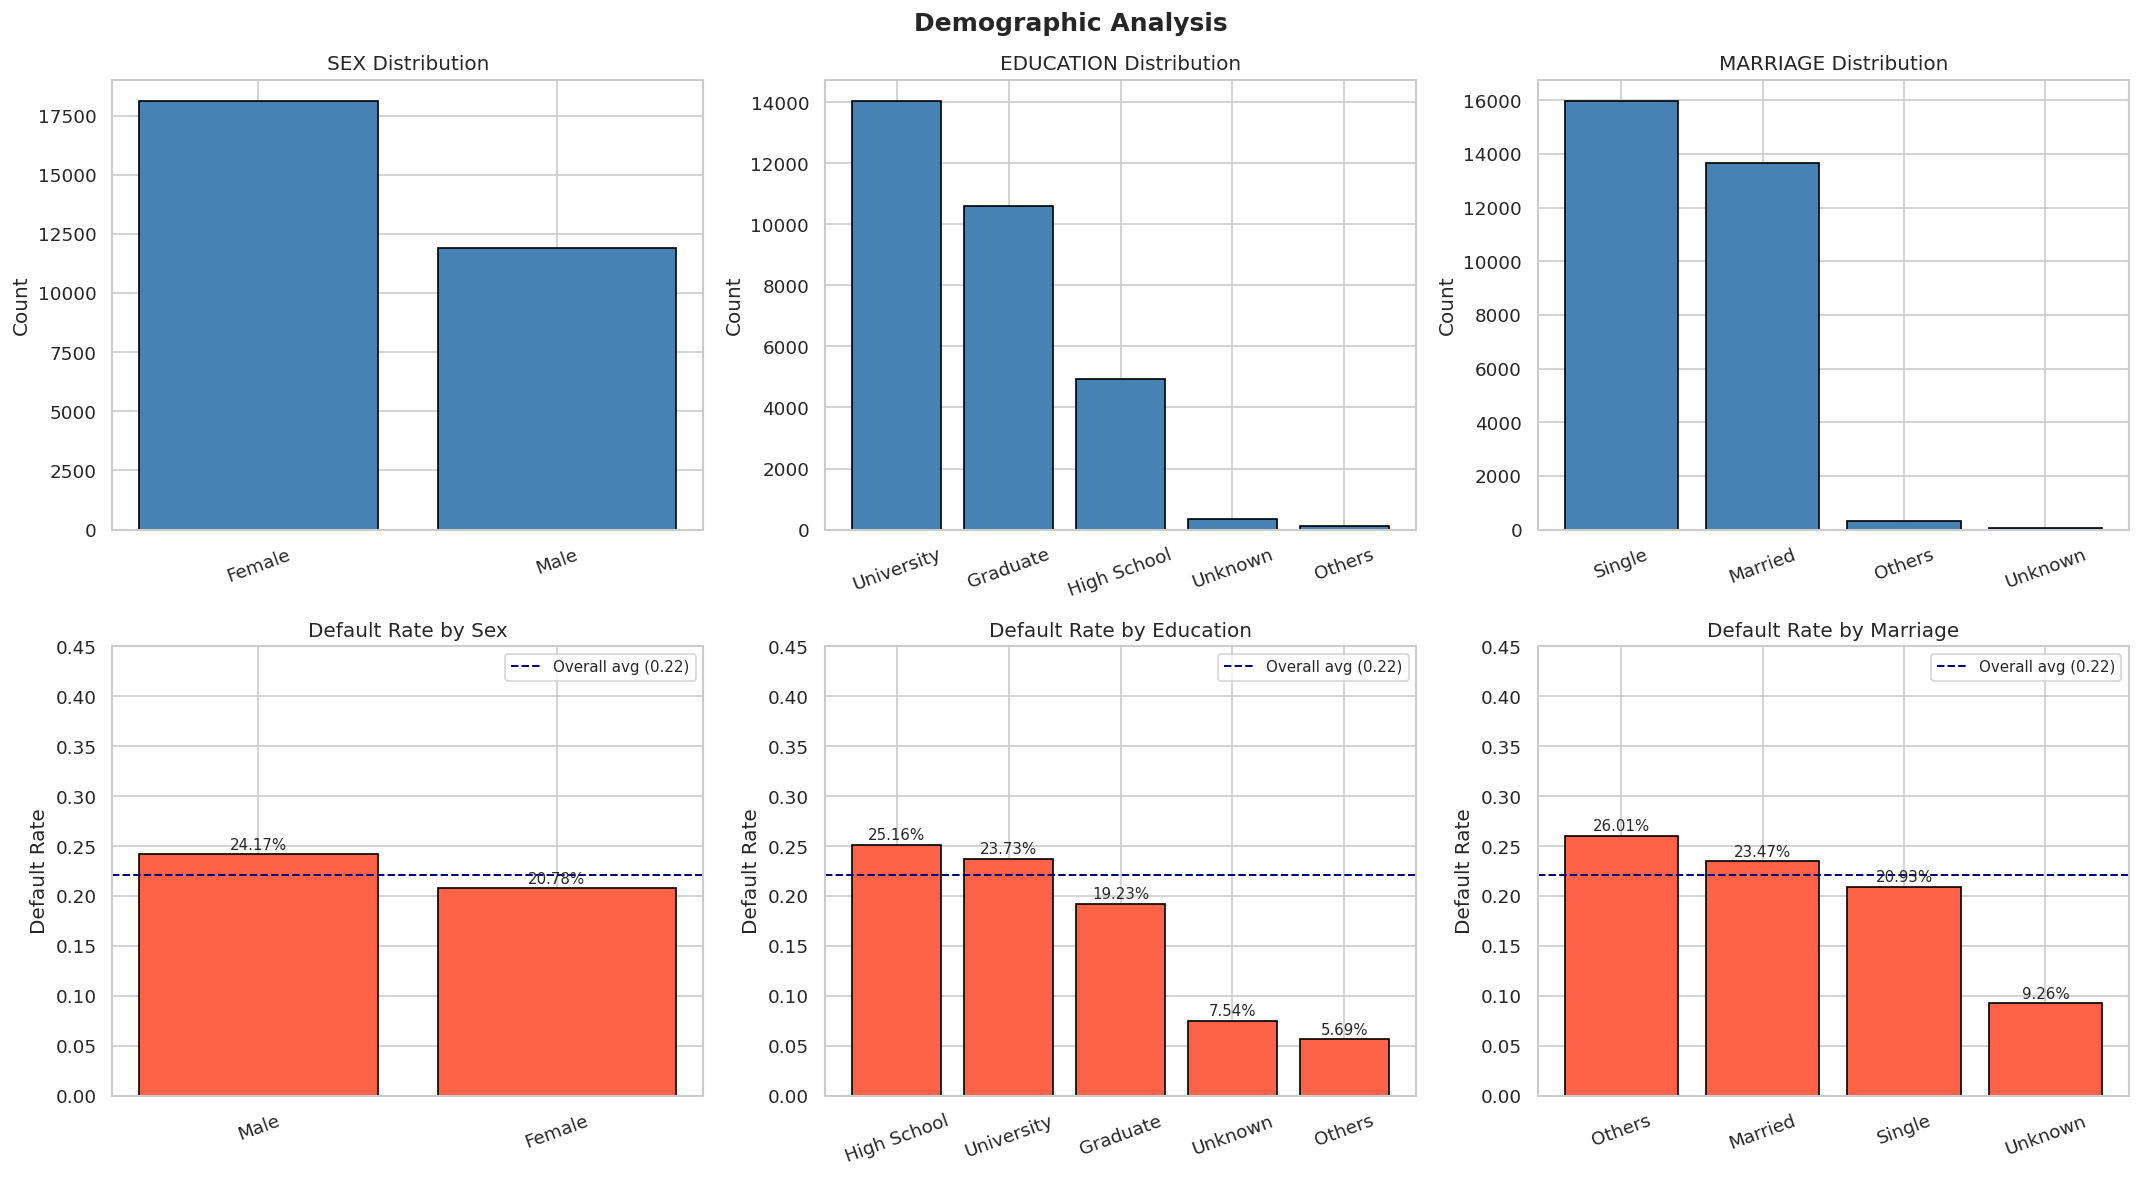

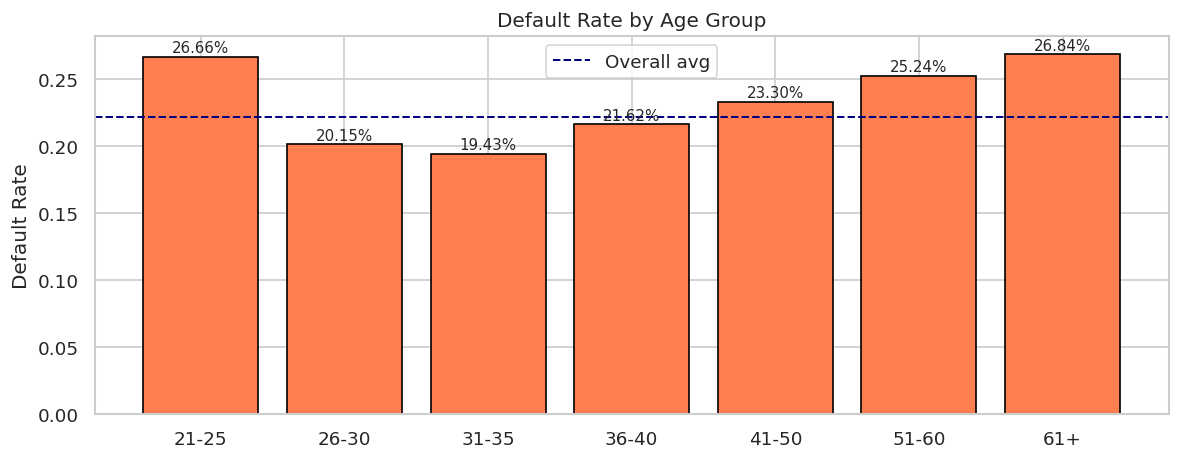

In [ ]:
# Remap for readability
df["SEX_label"]       = df["SEX"].map({1:"Male", 2:"Female"})
df["EDUCATION_label"] = df["EDUCATION"].map({
    0:"Unknown", 1:"Graduate", 2:"University",
    3:"High School", 4:"Others", 5:"Unknown", 6:"Unknown"})
df["MARRIAGE_label"]  = df["MARRIAGE"].map({
    0:"Unknown", 1:"Married", 2:"Single", 3:"Others"})

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

cats = [
    ("SEX_label",       "Default Rate by Sex"),
    ("EDUCATION_label", "Default Rate by Education"),
    ("MARRIAGE_label",  "Default Rate by Marriage"),
]

# Top row: count distributions
for ax, (col, title) in zip(axes[0], cats):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color="steelblue", edgecolor="black")
    ax.set_title(col.replace("_label","") + " Distribution")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=20)

# Bottom row: default rates
for ax, (col, title) in zip(axes[1], cats):
    rate = df.groupby(col)["default"].mean().sort_values(ascending=False)
    bars = ax.bar(rate.index, rate.values, color="tomato", edgecolor="black")
    ax.set_title(title)
    ax.set_ylabel("Default Rate")
    ax.set_ylim(0, 0.45)
    ax.axhline(df["default"].mean(), color="navy", linestyle="--",
               linewidth=1.2, label=f"Overall avg ({df['default'].mean():.2f})")
    ax.legend(fontsize=9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f"{bar.get_height():.2%}", ha="center", fontsize=9)
    ax.tick_params(axis="x", rotation=20)

plt.suptitle("Demographic Analysis", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Age group analysis
df["age_group"] = pd.cut(df["AGE"],
    bins=[20,25,30,35,40,50,60,80],
    labels=["21-25","26-30","31-35","36-40","41-50","51-60","61+"])
age_rate = df.groupby("age_group", observed=True)["default"].mean().reset_index()

plt.figure(figsize=(10, 4))
bars = plt.bar(age_rate["age_group"].astype(str),
               age_rate["default"], color="coral", edgecolor="black")
plt.axhline(df["default"].mean(), color="navy", linestyle="--",
            linewidth=1.2, label="Overall avg")
plt.title("Default Rate by Age Group")
plt.ylabel("Default Rate")
plt.legend()
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.003,
             f"{bar.get_height():.2%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# ─── ML NOTE ───────────────────────────────────────────────────────
# Education 0/5/6 → collapse to "Unknown" (reduce noise)
# Marriage 0       → collapse to "Unknown"
# Age              → use as CONTINUOUS (tree models) or
#                    age_group ORDINAL ENCODED (linear models)
# SEX              → binary 0/1 (already numeric, keep as-is)
# ─── DL NOTE ───────────────────────────────────────────────────────
# For MLP: one-hot encode EDUCATION (6 cats) and MARRIAGE (4 cats)
# SEX, AGE → pass as numeric directly
# Embedding layers NOT needed (too few categories for embeddings to help)
# ───────────────────────────────────────────────────────────────────

##Payment History Analysis

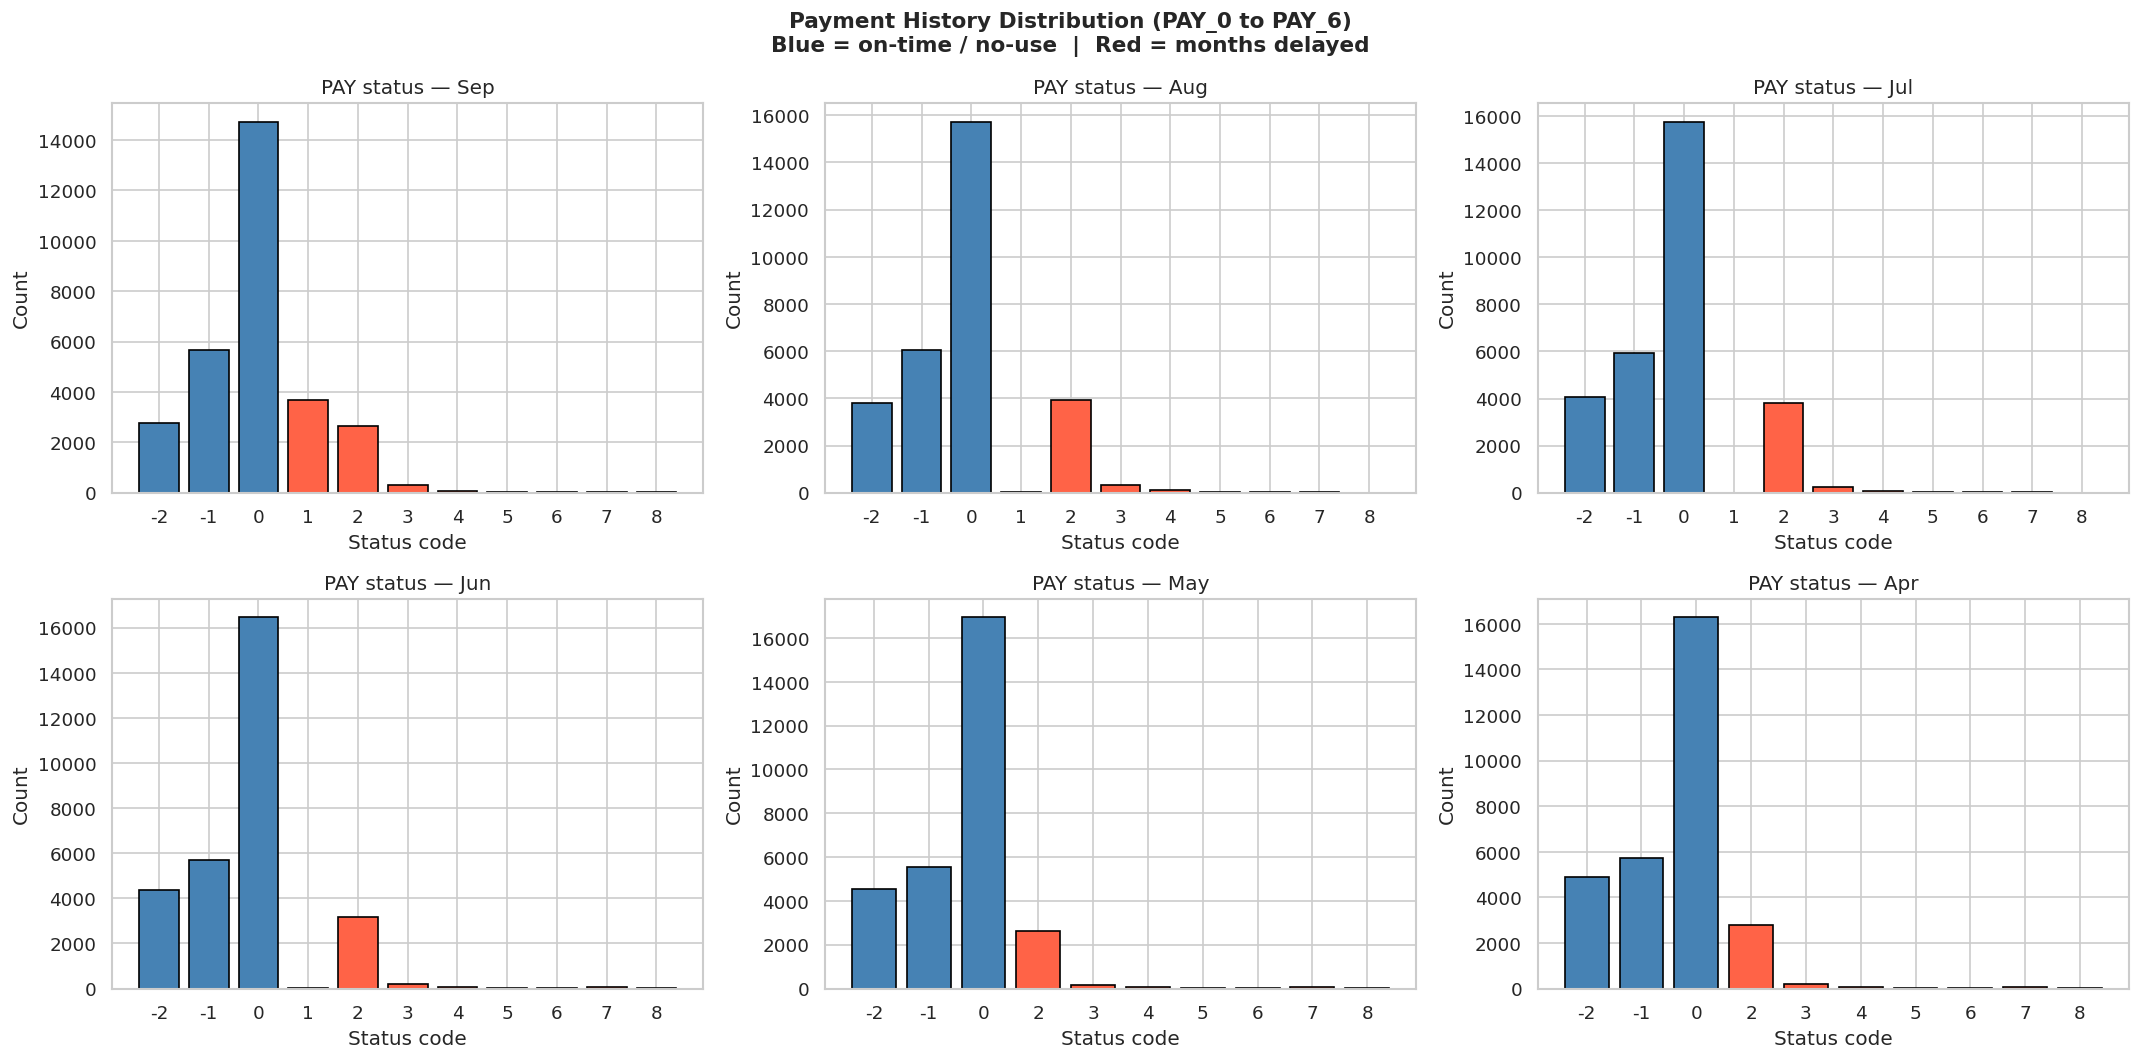

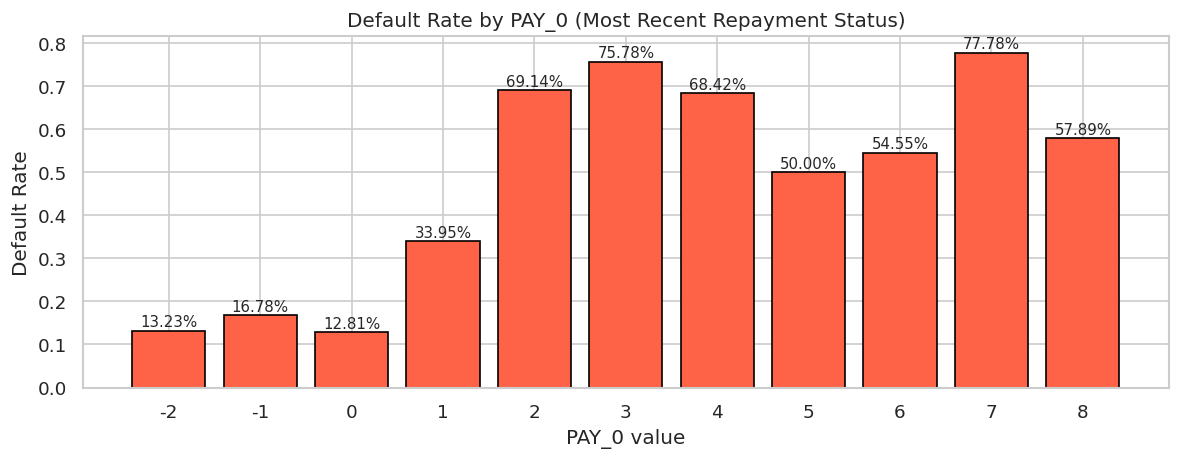

In [ ]:
pay_cols = ["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]
labels   = ["Sep","Aug","Jul","Jun","May","Apr"]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))

for ax, col, lbl in zip(axes.flatten(), pay_cols, labels):
    vc = df[col].value_counts().sort_index()
    ax.bar(vc.index.astype(str), vc.values,
           color=["tomato" if x > 0 else "steelblue" for x in vc.index],
           edgecolor="black")
    ax.set_title(f"PAY status — {lbl}")
    ax.set_xlabel("Status code")
    ax.set_ylabel("Count")

plt.suptitle("Payment History Distribution (PAY_0 to PAY_6)\n"
             "Blue = on-time / no-use  |  Red = months delayed",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Default rate by PAY_0 (most predictive single feature)
pay0_rate = df.groupby("PAY_0")["default"].mean().reset_index()
plt.figure(figsize=(10, 4))
bars = plt.bar(pay0_rate["PAY_0"].astype(str),
               pay0_rate["default"], color="tomato", edgecolor="black")
plt.title("Default Rate by PAY_0 (Most Recent Repayment Status)")
plt.xlabel("PAY_0 value")
plt.ylabel("Default Rate")
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f"{bar.get_height():.2%}", ha="center", fontsize=9)
plt.tight_layout()
plt.show()

# ─── ML NOTE ───────────────────────────────────────────────────────
# PAY_0 is the SINGLE strongest predictor (MI score will confirm)
# Treat PAY_0–PAY_6 as ORDINAL (−2 ≤ x ≤ 8) → keep as integers
# Feature engineering: m ────────────────────────────────
# PAY columns are ordinal → map to embedding OR pass as float
# Add engineered: consecutive_delays (rolling streak), delay_trend
# Normalize PAY values to [0,1] range before MLP input
# ───────────────────────────────────────────────────────────────────

##Bill & Payment Amounts

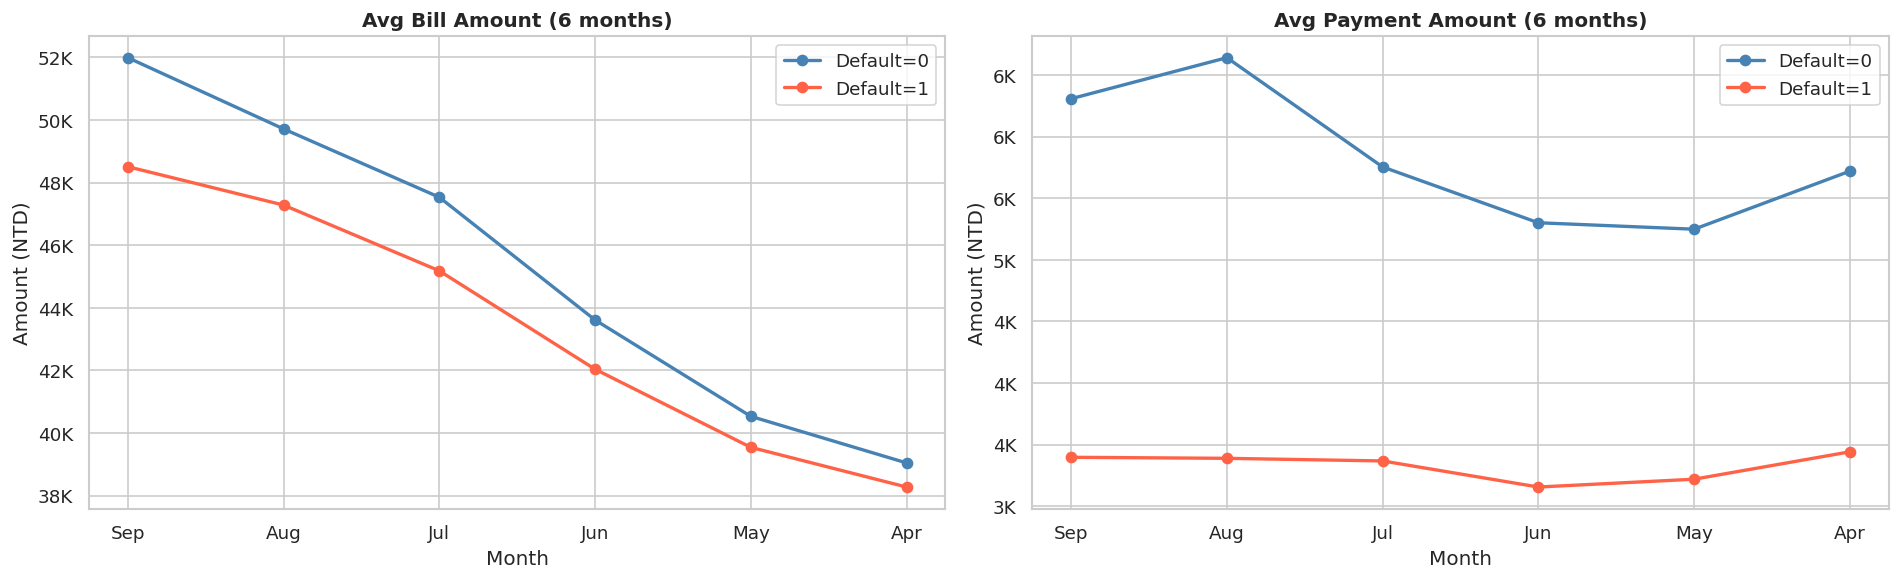

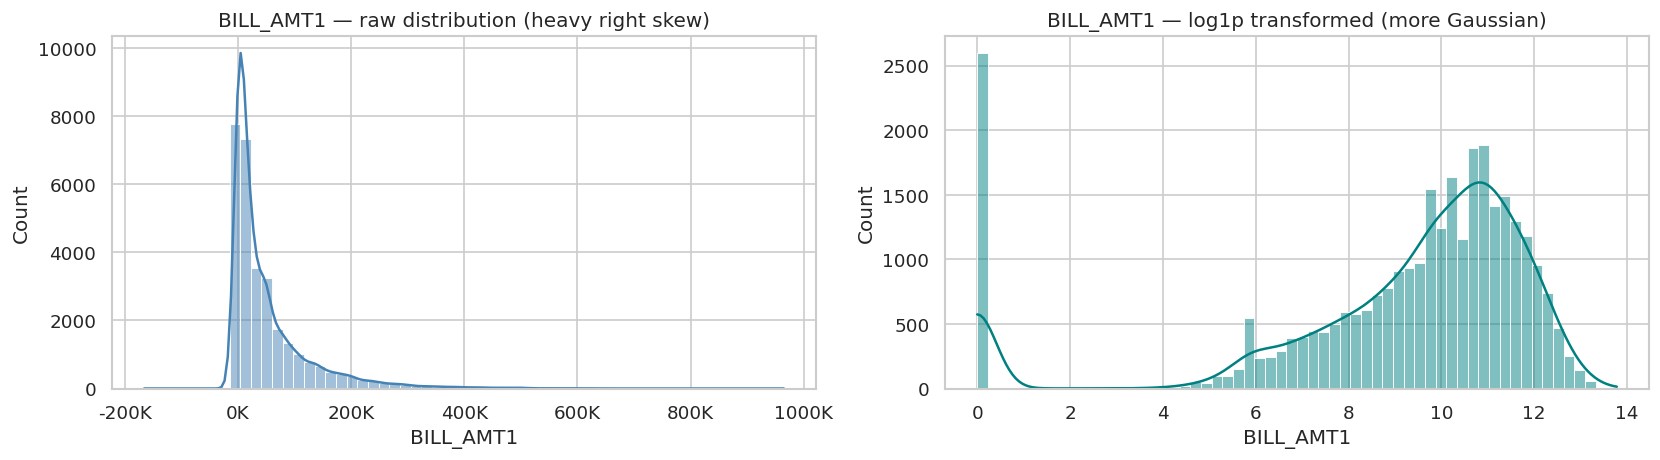

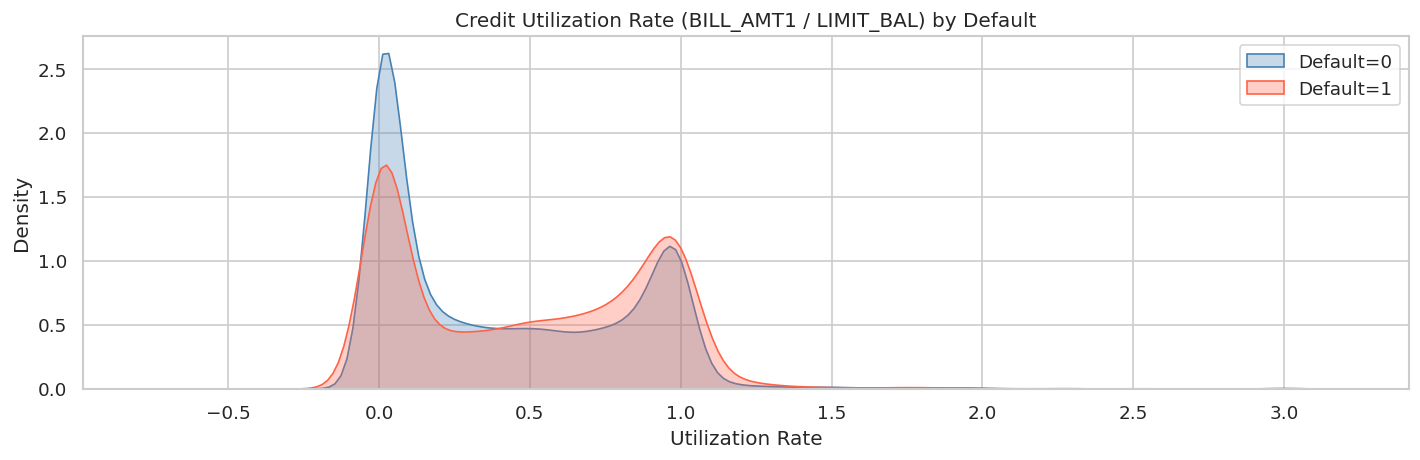

In [ ]:
bill_cols = [f"BILL_AMT{i}" for i in range(1,7)]
pamt_cols = [f"PAY_AMT{i}"  for i in range(1,7)]
months    = ["Sep","Aug","Jul","Jun","May","Apr"]

# Trend lines by default status
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for label, color in [(0,"steelblue"), (1,"tomato")]:
    grp = df[df["default"] == label]
    axes[0].plot(months, grp[bill_cols].mean().values,
                 marker="o", color=color, linewidth=2,
                 label=f"Default={label}")
    axes[1].plot(months, grp[pamt_cols].mean().values,
                 marker="o", color=color, linewidth=2,
                 label=f"Default={label}")

for ax, title in zip(axes, ["Avg Bill Amount (6 months)",
                              "Avg Payment Amount (6 months)"]):
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Month")
    ax.set_ylabel("Amount (NTD)")
    ax.legend()
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))
plt.tight_layout()
plt.show()

# Distribution of BILL_AMT1 (log scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df["BILL_AMT1"], bins=60, ax=axes[0], color="steelblue", kde=True)
axes[0].set_title("BILL_AMT1 — raw distribution (heavy right skew)")
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}K"))

sns.histplot(np.log1p(df["BILL_AMT1"].clip(lower=0)),
             bins=60, ax=axes[1], color="teal", kde=True)
axes[1].set_title("BILL_AMT1 — log1p transformed (more Gaussian)")
plt.tight_layout()
plt.show()

# Utilization rate (Bill / Limit)
df["util_rate"] = df["BILL_AMT1"] / (df["LIMIT_BAL"] + 1)
fig, ax = plt.subplots(figsize=(12, 4))
for label, color in [(0,"steelblue"), (1,"tomato")]:
    sns.kdeplot(df[df["default"]==label]["util_rate"].clip(-1, 3),
                ax=ax, color=color, fill=True, alpha=0.3,
                label=f"Default={label}")
ax.set_title("Credit Utilization Rate (BILL_AMT1 / LIMIT_BAL) by Default")
ax.set_xlabel("Utilization Rate")
ax.legend()
plt.tight_layout()
plt.show()

# ─── ML NOTE ───────────────────────────────────────────────────────
# BILL_AMT columns: right-skewed → apply log1p transform
#   df[bill_cols] = np.log1p(df[bill_cols].clip(lower=0))
# Negative values (overpayments) → clip to 0 THEN log1p
# Use RobustScaler (not StandardScaler) for BILL/PAY amounts
# Key engineered features:
#   util_rate        = BILL_AMT1 / (LIMIT_BAL + 1)
#   avg_bill         = df[bill_cols].mean(axis=1)
#   avg_pay          = df[pamt_cols].mean(axis=1)
#   bill_trend       = BILL_AMT1 - BILL_AMT6  (rising debt signal)
#   pay_to_bill_ratio= PAY_AMT1 / (BILL_AMT1 + 1)
# ─── DL NOTE ───────────────────────────────────────────────────────
# For MLP: feed both raw + log1p versions as separate channels OR
#   apply BatchNorm1d on input layer to handle scale differences
# Engineered ratios (util_rate, pay_to_bill) are CRITICAL for DL
#   because MLP cannot discover ratios itself unlike trees
# All continuous features → StandardScaler after log1p
# ───────────────────────────────────────────────────────────────────

##Correlation Analysis

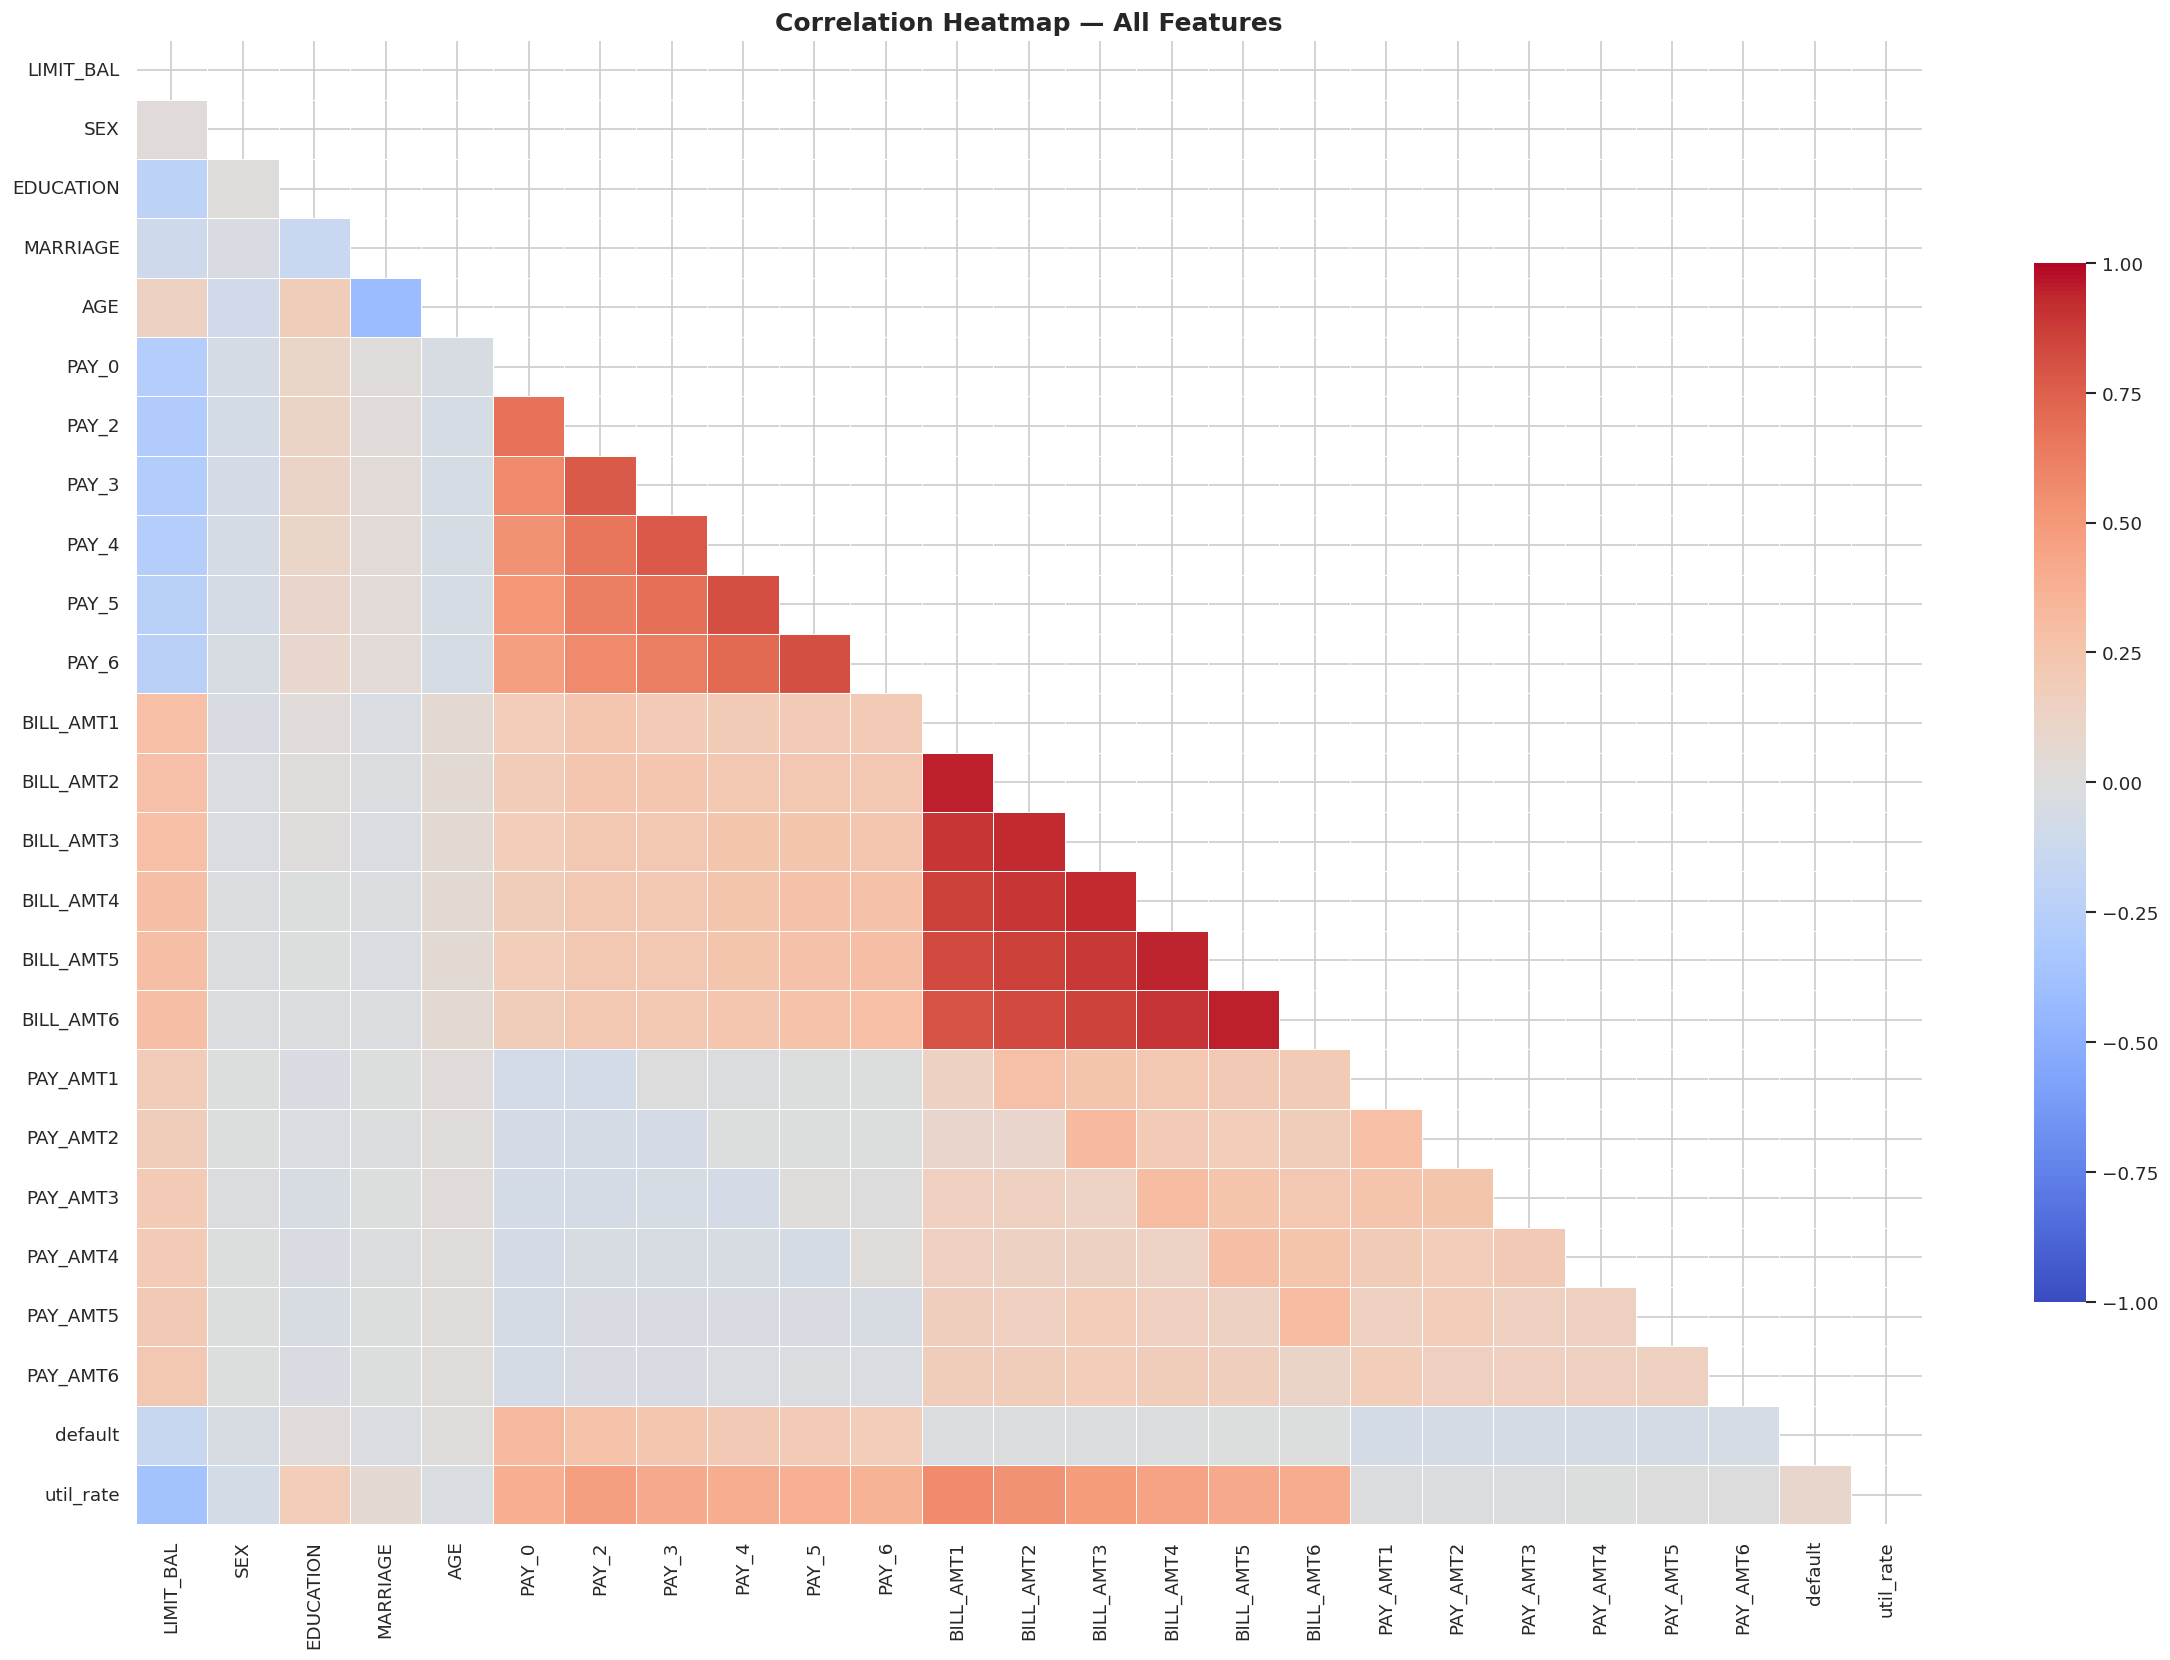

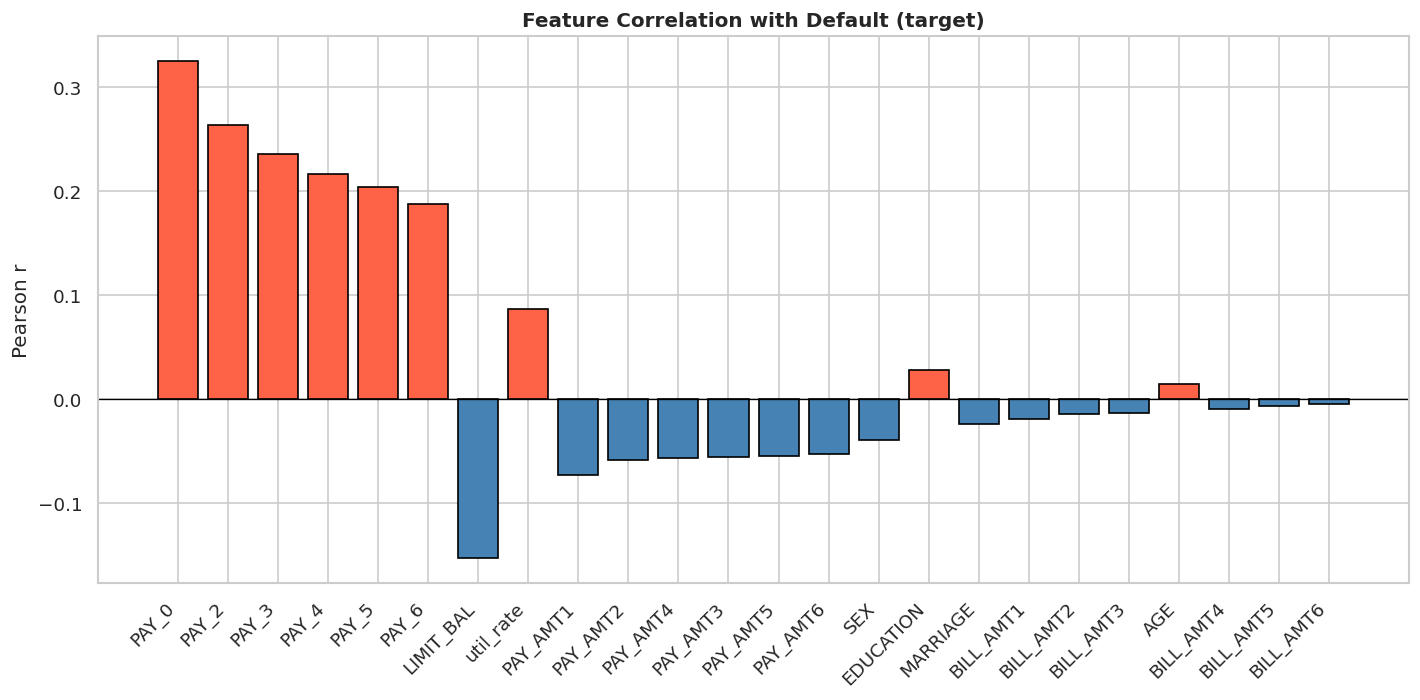

In [ ]:
# Full correlation heatmap
plt.figure(figsize=(20, 14))
num_df = df.drop(columns=["SEX_label","EDUCATION_label",
                           "MARRIAGE_label","age_group"], errors="ignore")
corr = num_df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, cmap="coolwarm",
            linewidths=0.3, vmin=-1, vmax=1,
            cbar_kws={"shrink": 0.7})
plt.title("Correlation Heatmap — All Features", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = corr["default"].drop("default").sort_values(key=abs, ascending=False)
plt.figure(figsize=(12, 6))
colors = ["tomato" if v > 0 else "steelblue" for v in target_corr.values]
plt.bar(target_corr.index, target_corr.values, color=colors, edgecolor="black")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Feature Correlation with Default (target)", fontweight="bold")
plt.ylabel("Pearson r")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# ─── ML NOTE ───────────────────────────────────────────────────────
# BILL_AMT1–6 are highly inter-correlated (r > 0.9)
#   → For Logistic Regression: drop BILL_AMT2–6, keep only BILL_AMT1
#     OR use PCA to compress 6 bill columns into 2 components
#   → For tree models (RF/XGB/LGBM): keep all — trees handle multicollinearity
# PAY_0 has highest positive correlation with default (~0.32)
# LIMIT_BAL has negative correlation — higher limit → less likely to default
# ─── DL NOTE ───────────────────────────────────────────────────────
# MLP is also affected by high multicollinearity → causes gradient issues
# Recommended: PCA the 6 BILL_AMT columns → 2 components → feed to MLP
# OR simply let BatchNorm + Dropout regularize away redundancy
# ───────────────────────────────────────────────────────────────────

##Statistical Summary (Outliers + Skewness)

─── TOP SKEWED FEATURES ───
PAY_AMT2     30.453817
PAY_AMT3     17.216635
PAY_AMT1     14.668364
PAY_AMT4     12.904985
PAY_AMT5     11.127417
PAY_AMT6     10.640727
BILL_AMT3     3.087830
BILL_AMT5     2.876380
BILL_AMT6     2.846645
BILL_AMT4     2.821965
dtype: float64


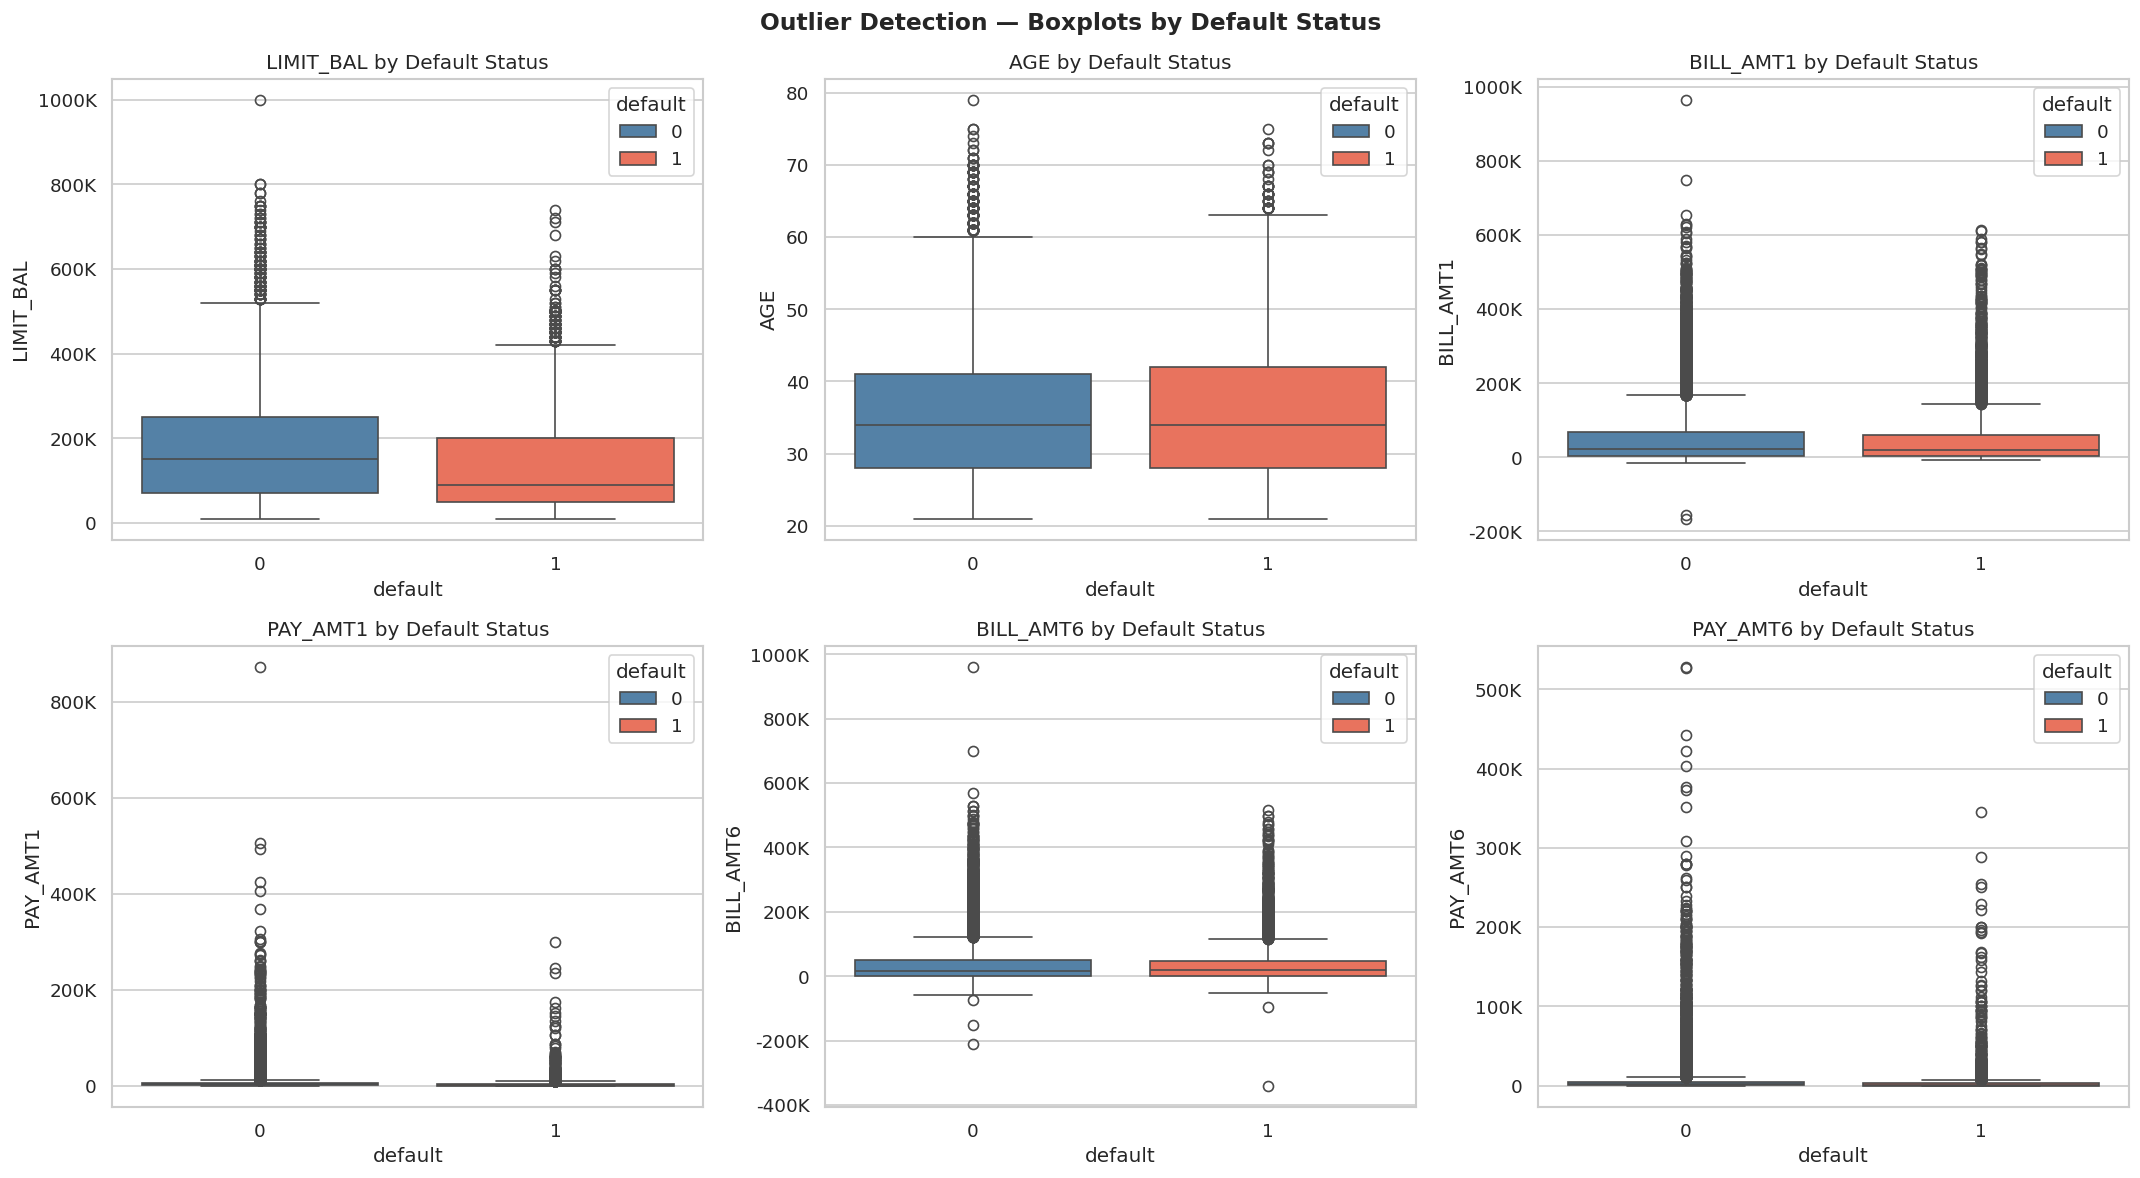


─── IQR OUTLIER COUNTS ───
  LIMIT_BAL      :   167 outliers (0.6%)
  BILL_AMT1      :  2400 outliers (8.0%)
  PAY_AMT1       :  2745 outliers (9.2%)
  BILL_AMT6      :  2693 outliers (9.0%)
  PAY_AMT6       :  2958 outliers (9.9%)


In [ ]:
# Skewness table
skew_df = num_df.drop(columns=["default"]).skew().sort_values(ascending=False)
print("─── TOP SKEWED FEATURES ───")
print(skew_df.head(10))

# Boxplots for outlier detection
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
cols_to_check = ["LIMIT_BAL","AGE","BILL_AMT1","PAY_AMT1","BILL_AMT6","PAY_AMT6"]

for ax, col in zip(axes.flatten(), cols_to_check):
    sns.boxplot(x="default", y=col, data=df, ax=ax,
                palette={0:"steelblue", 1:"tomato"},hue="default",)
    ax.set_title(f"{col} by Default Status")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(
        lambda x, _: f"{x/1000:.0f}K" if abs(x) >= 1000 else f"{x:.0f}"))

plt.suptitle("Outlier Detection — Boxplots by Default Status",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# IQR outlier count
print("\n─── IQR OUTLIER COUNTS ───")
for col in ["LIMIT_BAL","BILL_AMT1","PAY_AMT1","BILL_AMT6","PAY_AMT6"]:
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f"  {col:15s}: {n:5d} outliers ({n/len(df)*100:.1f}%)")

# ─── ML NOTE ───────────────────────────────────────────────────────
# DO NOT remove outliers — they may be true defaulters
# Strategy: cap at 99th percentile (winsorization) for linear models
#   from scipy.stats import mstats
#   df[bill_cols] = df[bill_cols].apply(
#       lambda x: mstats.winsorize(x, limits=[0, 0.01]))
# Tree models (RF/XGB/LGBM): outliers don't matter — trees split on rank
# Use RobustScaler (uses IQR) instead of StandardScaler for linear models
# ─── DL NOTE ───────────────────────────────────────────────────────
# Outliers HURT MLP — gradient explosions, slow convergence
# Apply: log1p clip → then StandardScaler
# Add gradient clipping in training loop: torch.nn.utils.clip_grad_norm_
# Input BatchNorm1d acts as a second line of defense
# ───────────────────────────────────────────────────────────────────

##Mutual Information (Feature Importance Preview)

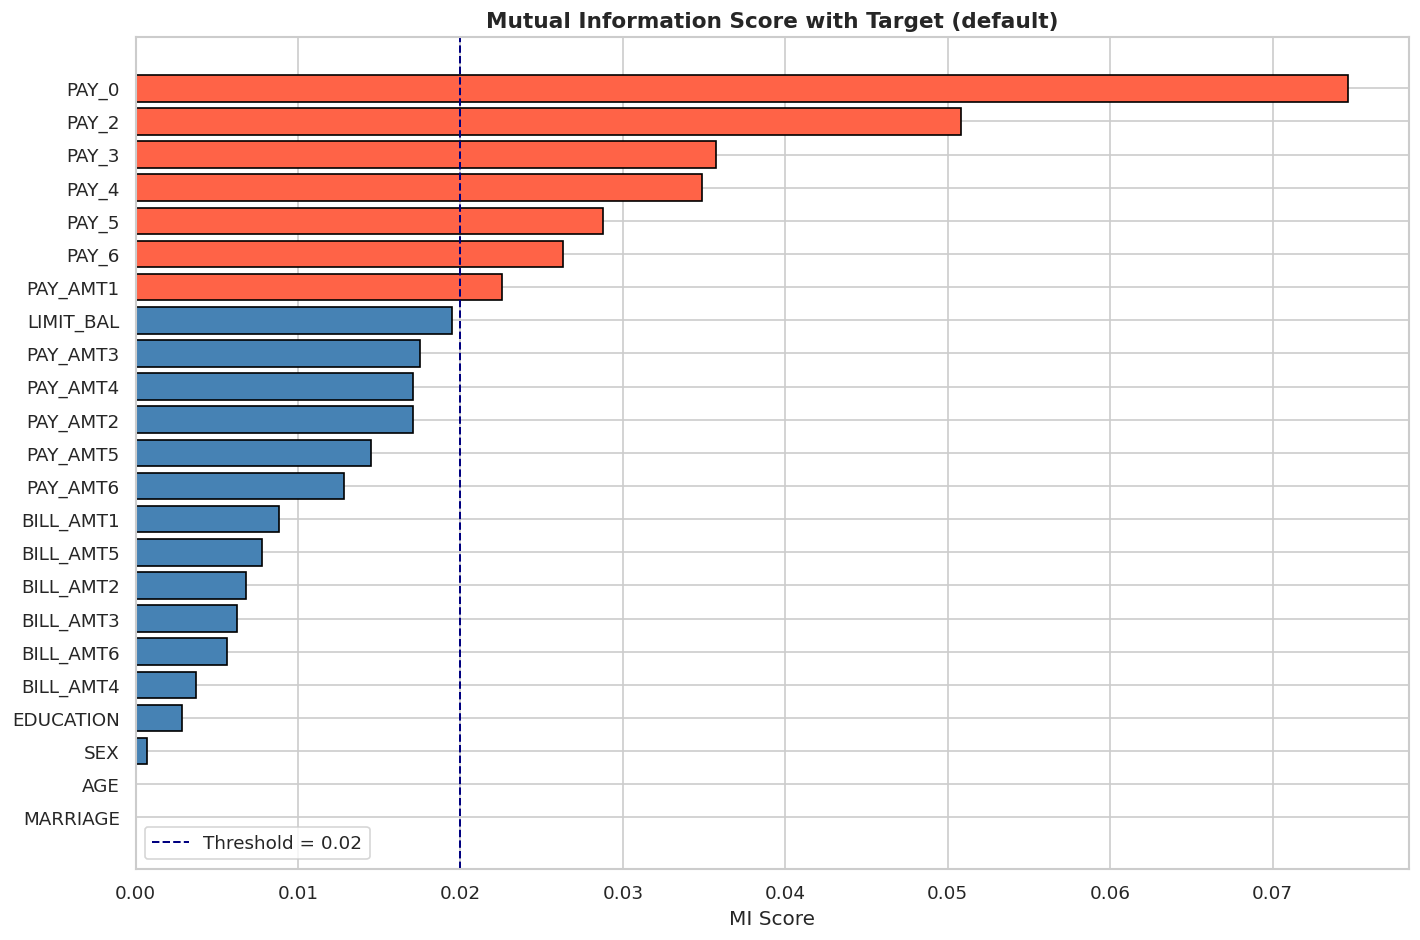

─── TOP 10 FEATURES BY MI ───
PAY_0        0.074656
PAY_2        0.050845
PAY_3        0.035747
PAY_4        0.034874
PAY_5        0.028759
PAY_6        0.026311
PAY_AMT1     0.022586
LIMIT_BAL    0.019485
PAY_AMT3     0.017493
PAY_AMT4     0.017106
dtype: float64


In [ ]:
X_mi = df.drop(columns=["default","SEX_label","EDUCATION_label",
                          "MARRIAGE_label","age_group","util_rate"],
                errors="ignore").fillna(0)
y_mi = df["default"]

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=42)
mi_df = pd.Series(mi_scores, index=X_mi.columns).sort_values(ascending=True)

plt.figure(figsize=(12, 8))
colors = ["tomato" if v > 0.02 else "steelblue" for v in mi_df.values]
plt.barh(mi_df.index, mi_df.values, color=colors, edgecolor="black")
plt.axvline(0.02, color="navy", linestyle="--", linewidth=1.2,
            label="Threshold = 0.02")
plt.title("Mutual Information Score with Target (default)",
          fontsize=13, fontweight="bold")
plt.xlabel("MI Score")
plt.legend()
plt.tight_layout()
plt.show()

print("─── TOP 10 FEATURES BY MI ───")
print(mi_df.sort_values(ascending=False).head(10))

# ─── ML NOTE ───────────────────────────────────────────────────────
# Expected top features: PAY_0, PAY_2, PAY_3, LIMIT_BAL, BILL_AMT1
# Low MI (<0.01): PAY_AMT4–6, MARRIAGE, SEX → consider dropping for
#   Logistic Regression to reduce noise
# Keep ALL for tree models (XGB handles irrelevant features well)
# ─── DL NOTE ───────────────────────────────────────────────────────
# MLP benefits from ALL features if properly normalized
# But: add feature selection as optional ablation experiment
#   → train MLP with top-15 MI features vs all → compare AUC
# PAY_0–PAY_6 sequence → can also be fed to a 1D-Conv or GRU layer
#   as a time-series of payment behavior (advanced architecture)
# ───────────────────────────────────────────────────────────────────

#EDA Summary & Recommendations Table

In [ ]:
summary = {
    "Finding": [
        "Class imbalance (22% default)",
        "EDUCATION has undocumented values 0,5,6",
        "MARRIAGE has undocumented value 0",
        "BILL_AMT1–6 are heavily right-skewed",
        "BILL_AMT1–6 are highly correlated (r>0.9)",
        "PAY_0 is strongest predictor",
        "LIMIT_BAL: higher = less default",
        "Negative BILL_AMT values exist (overpayments)",
        "PAY_AMT outliers (max = 1.68M NTD)",
        "Defaulters show rising bill + flat payments",
    ],
    "ML Action": [
        "class_weight='balanced' | scale_pos_weight=3.52",
        "Collapse 0,5,6 → 'Unknown', ordinal encode",
        "Collapse 0 → 'Unknown', ordinal encode",
        "log1p transform → RobustScaler",
        "Keep all for trees | PCA(2) for LR",
        "Keep raw + engineer: max_delay, times_delayed",
        "Keep as continuous, standard scale",
        "Clip to 0 before log1p",
        "Winsorize at 99th pct for LR | keep for trees",
        "Engineer: bill_trend, pay_to_bill_ratio",
    ],
    "Deep Learning Action": [
        "Focal Loss (alpha=0.75, gamma=2)",
        "One-hot encode (6 categories)",
        "One-hot encode (4 categories)",
        "log1p + StandardScaler + Input BatchNorm",
        "PCA(2) OR let BatchNorm+Dropout handle it",
        "Engineer: consecutive_delays, delay_trend",
        "StandardScaler, feed as float32",
        "Clip to 0 before log1p",
        "clip + log1p + gradient clipping in training",
        "Feed as extra engineered features to MLP",
    ]
}

summary_df = pd.DataFrame(summary)
summary_df.style \
    .set_properties(**{"text-align":"left","font-size":"12px"}) \
    .set_table_styles([{"selector":"th",
                        "props":[("background","#2c3e50"),
                                 ("color","white"),
                                 ("font-size","12px")]}]) \
    .hide(axis="index")

Finding,ML Action,Deep Learning Action
Class imbalance (22% default),class_weight='balanced' | scale_pos_weight=3.52,"Focal Loss (alpha=0.75, gamma=2)"
"EDUCATION has undocumented values 0,5,6","Collapse 0,5,6 → 'Unknown', ordinal encode",One-hot encode (6 categories)
MARRIAGE has undocumented value 0,"Collapse 0 → 'Unknown', ordinal encode",One-hot encode (4 categories)
BILL_AMT1–6 are heavily right-skewed,log1p transform → RobustScaler,log1p + StandardScaler + Input BatchNorm
BILL_AMT1–6 are highly correlated (r>0.9),Keep all for trees | PCA(2) for LR,PCA(2) OR let BatchNorm+Dropout handle it
PAY_0 is strongest predictor,"Keep raw + engineer: max_delay, times_delayed","Engineer: consecutive_delays, delay_trend"
LIMIT_BAL: higher = less default,"Keep as continuous, standard scale","StandardScaler, feed as float32"
Negative BILL_AMT values exist (overpayments),Clip to 0 before log1p,Clip to 0 before log1p
PAY_AMT outliers (max = 1.68M NTD),Winsorize at 99th pct for LR | keep for trees,clip + log1p + gradient clipping in training
Defaulters show rising bill + flat payments,"Engineer: bill_trend, pay_to_bill_ratio",Feed as extra engineered features to MLP
